# Retail Insights from Superstore Data

Exploratory data analysis of Superstore retail transactions to understand sales, profit, regional and product performance.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('C:\\Users\\Hp\\Desktop\\Advanced_Data_Sciecne-LAB\\Assignment_3\\Project3\\1776310869-P1-Retail Insights from Superstore Data.csv')
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## Dataset Overview

In [3]:
print('Dataset Shape:', df.shape)
print(df.columns.tolist())
df.info()

Dataset Shape: (9994, 13)
['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


## Data Quality Check

In [4]:
print('Missing Values:')
print(df.isnull().sum())
print('\nDuplicate Rows:', df.duplicated().sum())

Missing Values:
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Duplicate Rows: 17


## Overall Business Performance

In [5]:
print(f"Total Sales: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Total Quantity: {df['Quantity'].sum():,}")
df[['Sales','Quantity','Discount','Profit']].describe()

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Quantity: 37,873


,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


## Sales by Category

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


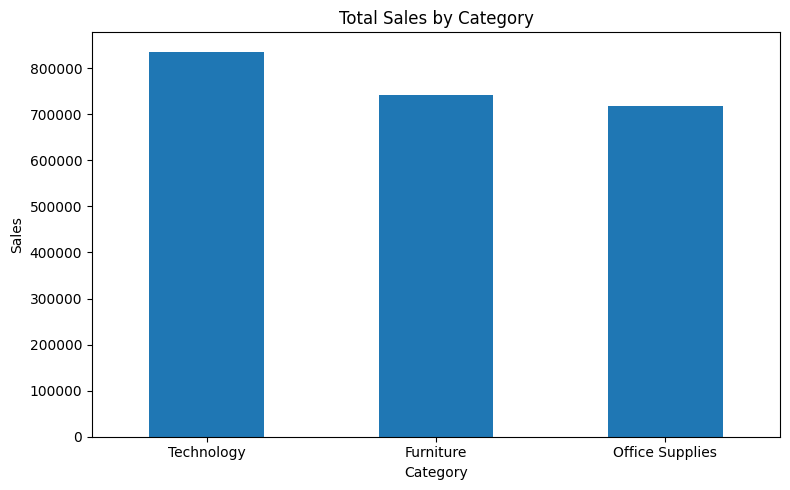

In [6]:
category_sales=df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)
plt.figure(figsize=(8,5)); category_sales.plot(kind='bar'); plt.title('Total Sales by Category'); plt.xlabel('Category'); plt.ylabel('Sales'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## Profit by Region

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


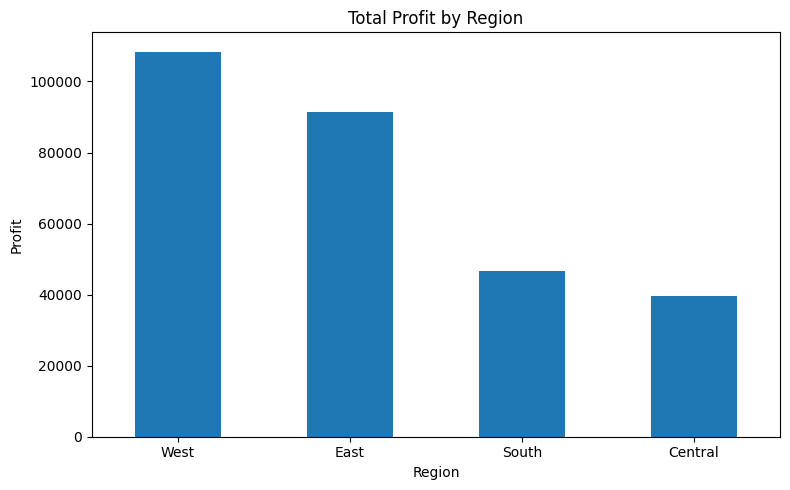

In [7]:
region_profit=df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print(region_profit)
plt.figure(figsize=(8,5)); region_profit.plot(kind='bar'); plt.title('Total Profit by Region'); plt.xlabel('Region'); plt.ylabel('Profit'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## Profit by Sub-Category

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64


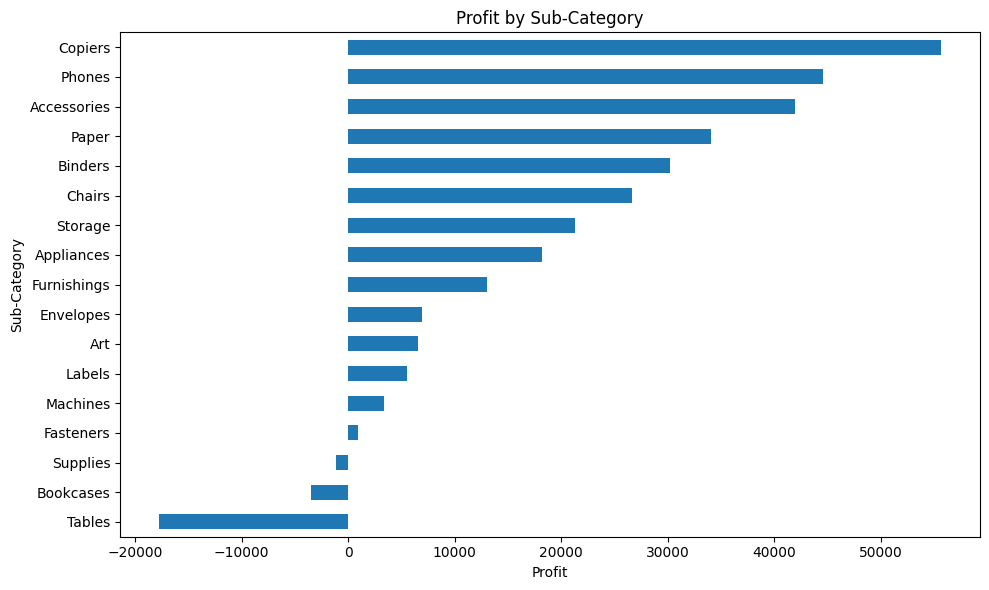

In [8]:
subcategory_profit=df.groupby('Sub-Category')['Profit'].sum().sort_values()
print(subcategory_profit)
plt.figure(figsize=(10,6)); subcategory_profit.plot(kind='barh'); plt.title('Profit by Sub-Category'); plt.xlabel('Profit'); plt.tight_layout(); plt.show()

## Discount and Profit Analysis

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64


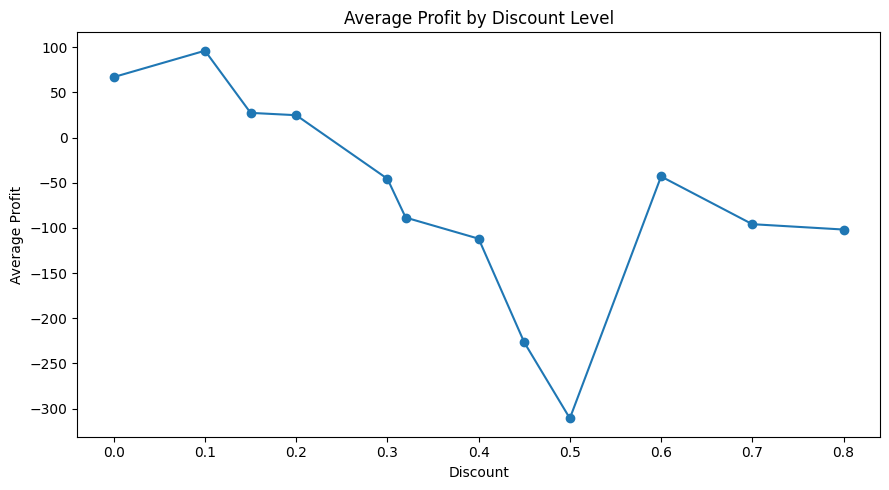

In [9]:
discount_profit=df.groupby('Discount')['Profit'].mean()
print(discount_profit)
plt.figure(figsize=(9,5)); plt.plot(discount_profit.index,discount_profit.values,marker='o'); plt.title('Average Profit by Discount Level'); plt.xlabel('Discount'); plt.ylabel('Average Profit'); plt.tight_layout(); plt.show()

## Conclusion

The analysis identifies patterns in sales and profitability across product categories, regions, sub-categories and discount levels. These insights can support data-driven decisions related to product strategy, regional performance and profitability improvement.